# Chap iv question 14

In [1]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
summarize)
import matplotlib.pyplot as plt
import seaborn as sns

# (a) Create a binary variable, mpg01, that contains a 1 if mpg is above its median and 0 if mpg is below its median

In [2]:

import numpy as np
import pandas as pd

# Load Auto dataset
from ISLP import load_data
Auto = load_data("Auto")

# Remove missing values
Auto = Auto.dropna()

# Calculate median mpg
median_mpg = Auto["mpg"].median()

print("Median mpg:", median_mpg)

# Create mpg01
Auto["mpg01"] = (Auto["mpg"] > median_mpg).astype(int)

print(Auto[["mpg", "mpg01"]].head())

Median mpg: 22.75
                            mpg  mpg01
name                                  
chevrolet chevelle malibu  18.0      0
buick skylark 320          15.0      0
plymouth satellite         18.0      0
amc rebel sst              16.0      0
ford torino                17.0      0


# (b) Explore the data graphically to investigate the association between mpg01 and the other features. Which features seem most useful for predicting mpg01?

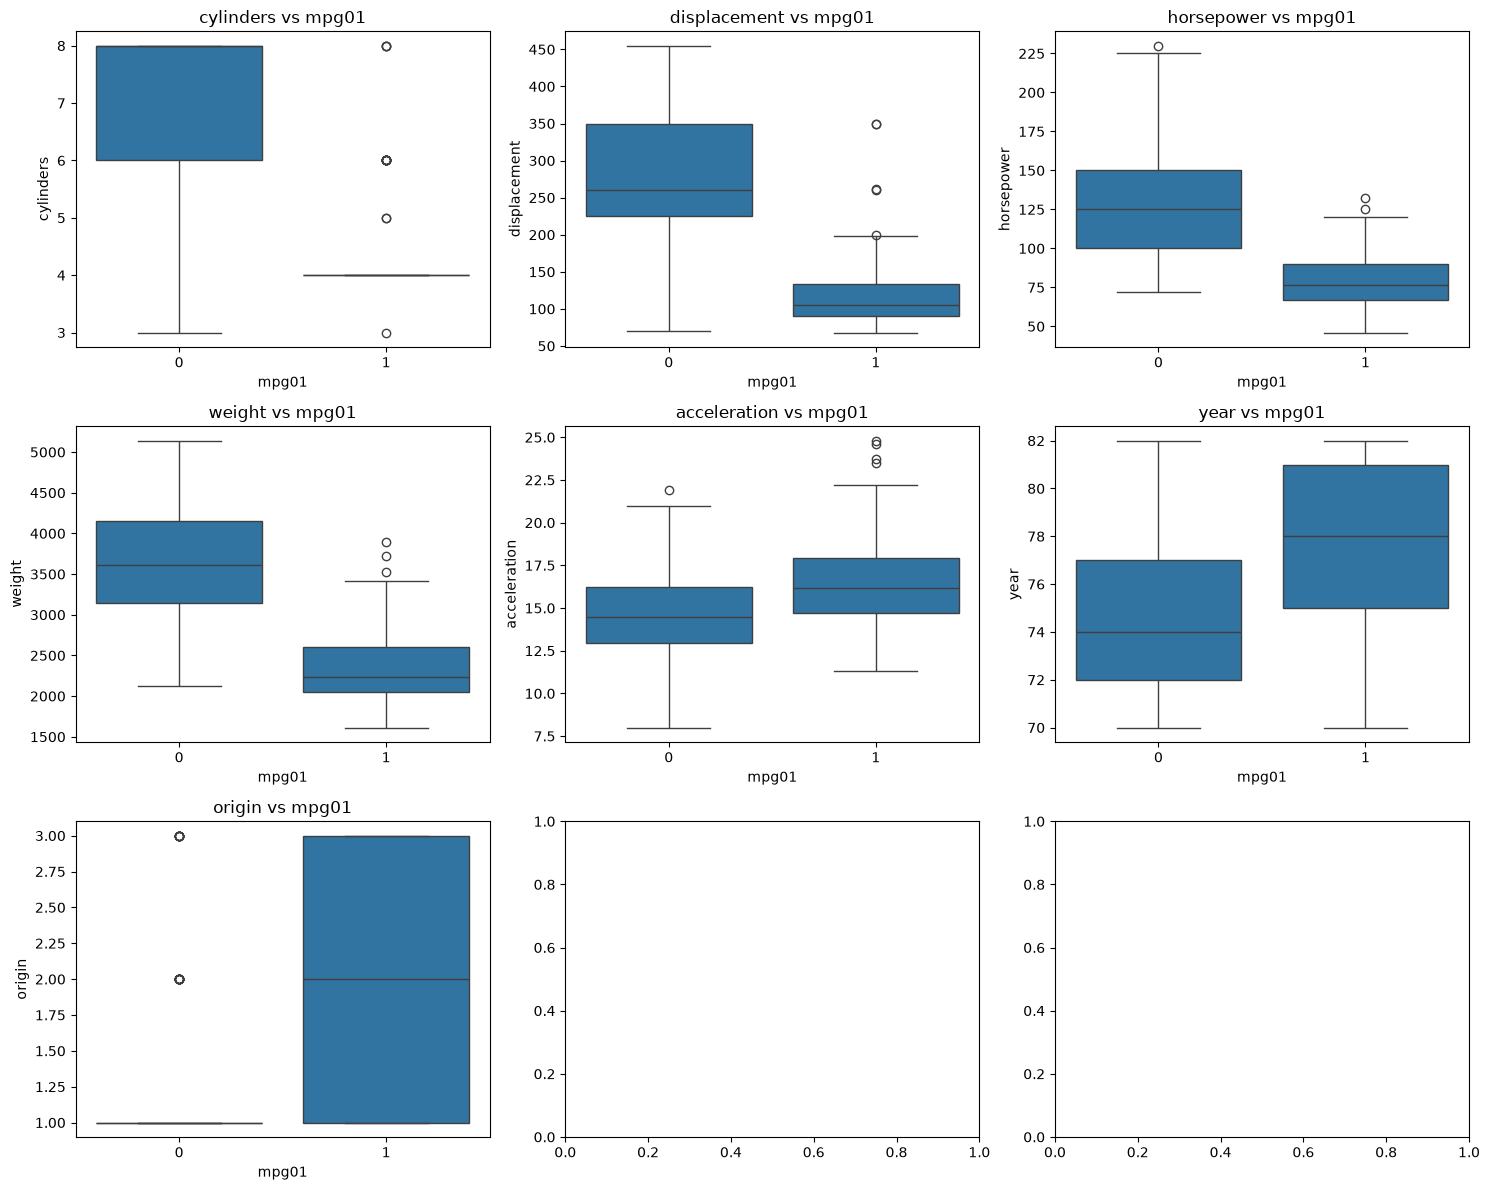

In [3]:


features = [
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "year",
    "origin"
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(
        x="mpg01",
        y=feature,
        data=Auto,
        ax=axes[i]
    )
    axes[i].set_title(f"{feature} vs mpg01")

plt.tight_layout()
plt.show()


# (c) Split the data into a training set and a test set.

In [4]:
from sklearn.model_selection import train_test_split

predictors = [
    "cylinders",
    "displacement",
    "horsepower",
    "weight"
]

X = Auto[predictors]
y = Auto["mpg01"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.5,
    random_state=1,
    stratify=y
)

print("Training observations:", len(X_train))
print("Test observations:", len(X_test))


Training observations: 196
Test observations: 196


# (d) Perform LDA on the training data to predict mpg01. What is the test error?

In [5]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score

lda = LinearDiscriminantAnalysis()

lda.fit(X_train, y_train)

y_pred_lda = lda.predict(X_test)

lda_error = np.mean(y_pred_lda != y_test)

print("LDA test error:", lda_error)
print("LDA test accuracy:", accuracy_score(y_test, y_pred_lda))


LDA test error: 0.11224489795918367
LDA test accuracy: 0.8877551020408163


# (e) Perform QDA on the training data to predict mpg01. What is the test error?

In [6]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

qda = QuadraticDiscriminantAnalysis()

qda.fit(X_train, y_train)

y_pred_qda = qda.predict(X_test)

qda_error = np.mean(y_pred_qda != y_test)

print("QDA test error:", qda_error)
print("QDA test accuracy:", accuracy_score(y_test, y_pred_qda))


QDA test error: 0.11734693877551021
QDA test accuracy: 0.8826530612244898


# (f) Perform logistic regression on the training data to predict mpg01. What is the test error?

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

logit = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

logit.fit(X_train, y_train)

y_pred_logit = logit.predict(X_test)

logit_error = np.mean(y_pred_logit != y_test)

print("Logistic regression test error:", logit_error)
print("Logistic regression accuracy:",
      accuracy_score(y_test, y_pred_logit))


Logistic regression test error: 0.11224489795918367
Logistic regression accuracy: 0.8877551020408163


# (g) Perform Naive Bayes on the training data to predict mpg01. What is the test error?

In [8]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

nb_error = np.mean(y_pred_nb != y_test)

print("Naive Bayes test error:", nb_error)
print("Naive Bayes accuracy:", accuracy_score(y_test, y_pred_nb))


Naive Bayes test error: 0.11224489795918367
Naive Bayes accuracy: 0.8877551020408163


# (h) Perform KNN with several values of K What test errors do you obtain? Which value of K performs best?

In [9]:
from sklearn.neighbors import KNeighborsClassifier

# Standardize the predictors before KNN
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

k_values = [1, 3, 5, 7, 10, 15, 20]

knn_errors = {}

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    y_pred_knn = knn.predict(X_test_scaled)

    error = np.mean(y_pred_knn != y_test)
    knn_errors[k] = error

for k, error in knn_errors.items():
    print(f"K = {k}: Test error = {error:.4f}")


K = 1: Test error = 0.0918
K = 3: Test error = 0.1020
K = 5: Test error = 0.1122
K = 7: Test error = 0.1071
K = 10: Test error = 0.1122
K = 15: Test error = 0.1122
K = 20: Test error = 0.1122
